**Author:** Gustavo Galvao

# Analysis of Educational Attainment as a Predictor for County-Level GDP

## Project Overview
This notebook investigates the relationship between human capital (measured by Bachelor's Degree attainment) and economic output (Real GDP) across Georgia's counties. The goal is to build a predictive model capable of estimating GDP trajectories based on educational shifts.

### The "Data Desert" Challenge (2003–2009)
A primary challenge of this study is the lack of annual education data prior to 2010. While county GDP data is available for the full 2003–2023 window, education data is anchored by the 2000 Decennial Census and the 2010 ACS estimates.

### Research Objectives
* **Baseline Validation:** Use the "Gold Standard" data (2010–2023) to establish a baseline correlation between Education and Total GDP.
* **Methodological Testing:** Compare three imputation methods (Linear Interpolation, Back-filling, and Baseline/Drop) to fill the 2003–2009 education gap.

### Modeling Strategy: Total GDP First
Due to heavy data suppression (NaNs) in industry-specific GDP columns many counties, this analysis prioritizes **Total Real GDP Growth** to maintain a consistent signal across all 159 counties.

## Notebook Structure
This notebook follows a modular workflow separated into 4 main chapters:

1.  **Data Ingestion & Cleaning:** Load TerraTrends dataset and filter for relevant predictors and years.
2. **Exploratory Data Analysis (EDA):**
    * Lagged Correlation Analysis ($t$ through $t-5$) to find the economic "reaction time."
    * Analyzing if change in education correlates better with GDP increase in opposition to pure higher education attainment percentage
3. **Imputation Experiment:**
    * **Dataset A:** Linear Interpolation (Steady growth assumption).
    * **Dataset B:** Back-filling (Stationary assumption).
    * **Dataset C:** Baseline (Excluding education metrics entirely).
4. **Model Benchmarking:** Comparing Mean Absolute Error (MAE) and $R^2$ across datasets to evaluate feature viability.

## Tech Stack
* **Language:** Python 3.10+
* **Libraries:** `pandas`, `scikit-learn`, `seaborn`
* **Data Sources:** IPUMS NHGIS (Census/ACS), Bureau of Economic Analysis (BEA)


# Data Ingestion and Cleaning

## Data Source and Loading

The notebook first begins by loading the TerraTrends updated data set (which now includes all population estimates from all counties from 2003 to 2023) which can be found in the [GitHub repository containing this notebook]().

In [ ]:
# Chapter 1: Data Ingestion & Cleaning
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuration constants
INPUT_DATA_PATH = "../data/input"
INPUT_FILE_NAME = "merged_data.csv"
TARGET_YEARS = list(range(2010, 2024))
PREDICTOR_COLUMN = "Bachelor_Degree_or_Higher_Pct"
TARGET_COLUMN = "Percent_Change_Real_GDP"
ID_COLUMNS = ["County", "Year"]
RELEVANT_COLUMNS = ID_COLUMNS + [TARGET_COLUMN] + [PREDICTOR_COLUMN]

# Loading and filtering
georgia_county_dataset_path = os.path.join(INPUT_DATA_PATH, INPUT_FILE_NAME)
georgia_county_df = pd.read_csv(georgia_county_dataset_path)

education_gdp_df = georgia_county_df[georgia_county_df["Year"].isin(TARGET_YEARS)][RELEVANT_COLUMNS]

# Display and health checks
print(f"Dataset shape: {education_gdp_df.shape}")
print(f"Missing values \n{education_gdp_df.isnull().sum()}")
education_gdp_df.head()

# EDA

Now, we begin working on analyzing how the data

In [15]:
def create_lagged_education_df(df: pd.DataFrame, max_lag: int, county_column_name: str, education_column_name: str) -> pd.DataFrame:
    new_df = df.copy()
    for i in range(max_lag + 1):
        new_column_name = f"education_t-{i}" if i > 0 else f"education_t"
        new_df[new_column_name] = new_df.groupby(county_column_name)[education_column_name].shift(i)

    return new_df

def display_lagged_scatter_plots(df: pd.DataFrame, max_lag: int, gdp_column_name: str, axs: plt.axes) -> None:
    for i in range(max_lag + 1):
        education_column_name = f"education_t-{i}" if i > 0 else f"education_t"
        valid_df = df.dropna(subset=education_column_name)
        sns.regplot(ax=axs[i], data=valid_df, x=education_column_name, y=gdp_column_name, line_kws={"color": "red"})
        axs[i].set_title(f"{i} year lagged education")
        axs[i].set_xlabel(f"Bachelor's attainment percentage ({i}) year lag")
        axs[i].set_ylabel(f"GDP change")

def calculate_education_gdp_correlation(df: pd.DataFrame, max_lag: int, gdp_column_name: str) -> list[float]:
    correlations = []
    for i in range(max_lag + 1):
        education_column_name = f"education_t-{i}" if i > 0 else f"education_t"
        valid_df = df.dropna(subset=education_column_name)
        corr = valid_df[gdp_column_name].corr(valid_df[education_column_name], method="spearman")
        correlations.append(corr)

    return correlations

def display_education_lags_correlation(correlations: list[float], max_lag: int) -> None:
    lags = list(range(max_lag + 1))
    plt.figure(figsize=(8, 4))
    plt.plot(lags, correlations, marker='o', linestyle='--', color='teal')
    plt.title("Correlation Strength by Lag Year")
    plt.xlabel("Years Lagged")
    plt.ylabel("Correlation")
    plt.grid(True, alpha=0.3)
    plt.show()


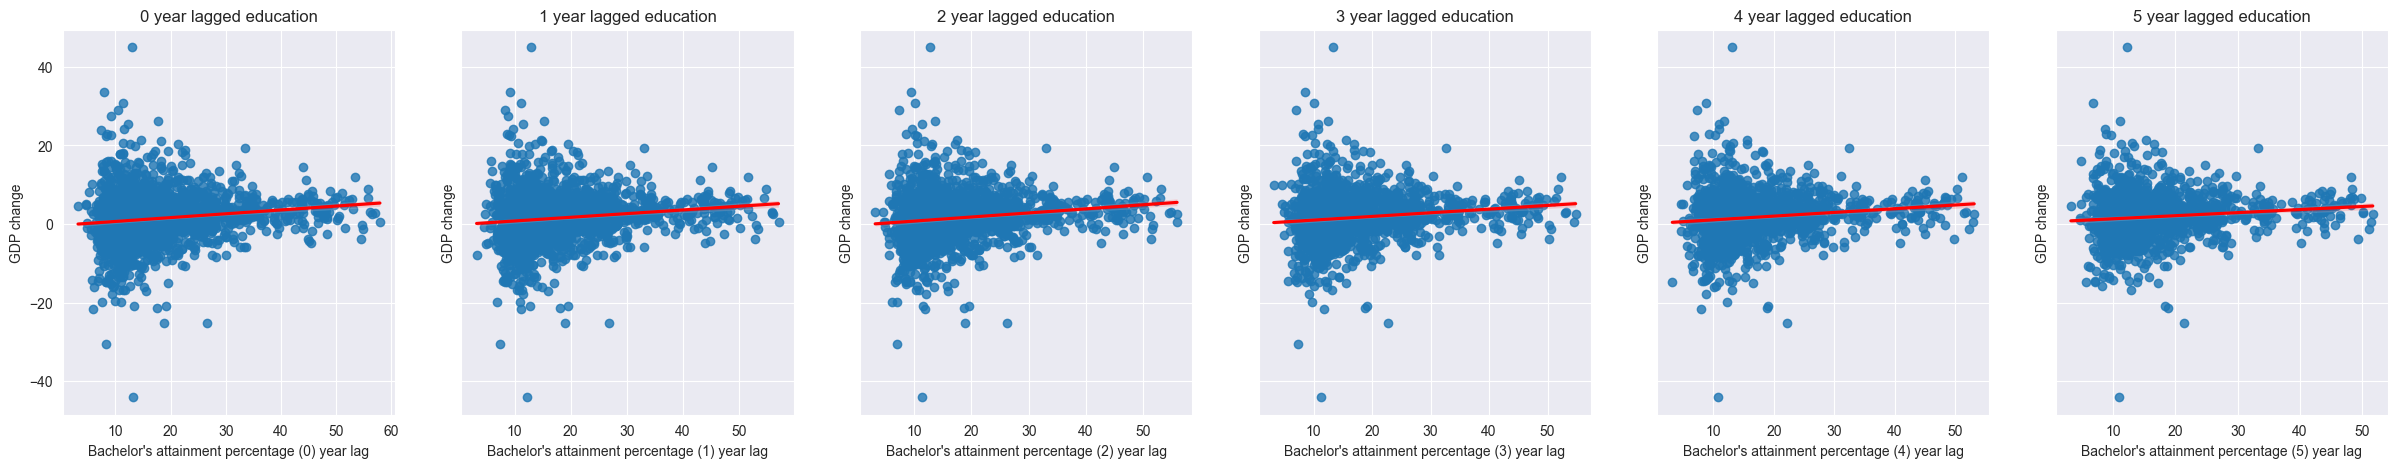

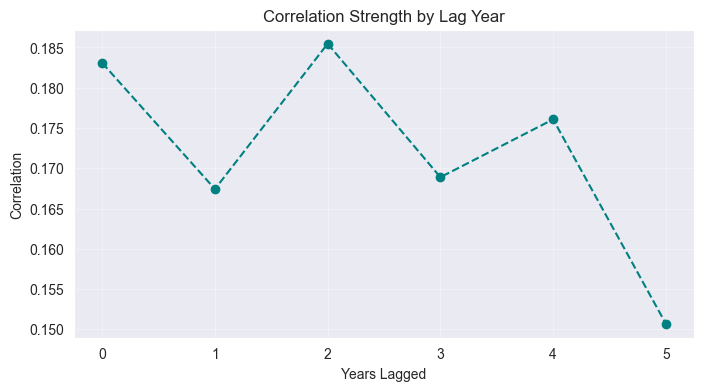

In [16]:
# Generate lagged education features
lag = 5
lagged_df = create_lagged_education_df(education_gdp_df, lag, "County", PREDICTOR_COLUMN)

# Display lagged education scatter plots
fig, axes = plt.subplots(nrows=1, ncols=lag+1, figsize=(30, 5), sharex=False, sharey=True)
display_lagged_scatter_plots(lagged_df, lag, TARGET_COLUMN, axes)
plt.show()

# Calculate and display plot of education lags vs. correlation with GDP
corrs = calculate_education_gdp_correlation(lagged_df, lag, TARGET_COLUMN)
display_education_lags_correlation(corrs, lag)
